In [17]:
# Import library

import glob
import os
import numpy as np
import pandas as pd
import skimage as ski
from skimage import io, filters
from skimage.filters import threshold_triangle, difference_of_gaussians
from skimage.morphology import disk, extrema
from skimage.measure import regionprops_table
from skimage.segmentation import watershed
from scipy import ndimage
from scipy.ndimage import distance_transform_edt
from skimage.color import label2rgb, gray2rgb
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
from skimage.feature import peak_local_max

In [18]:
# Accessibility

PATH = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/'

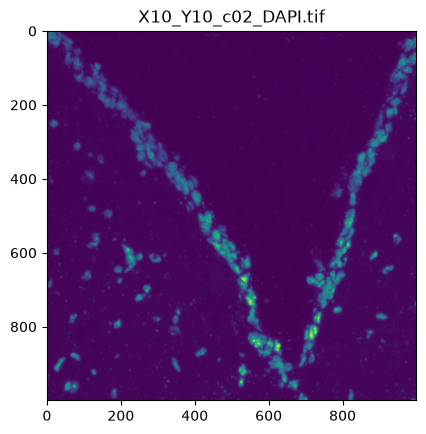

In [19]:
#13.1 - plot one image _ DAPI

from skimage import io as io
import matplotlib.pyplot as plt
path_image = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y2_c02_DAPI.tif'
im = io.imread(path_image) #read # misunderstanding(package and module)
plt.imshow(im)
plt.title ("X10_Y10_c02_DAPI.tif")#draw
plt.show() #show


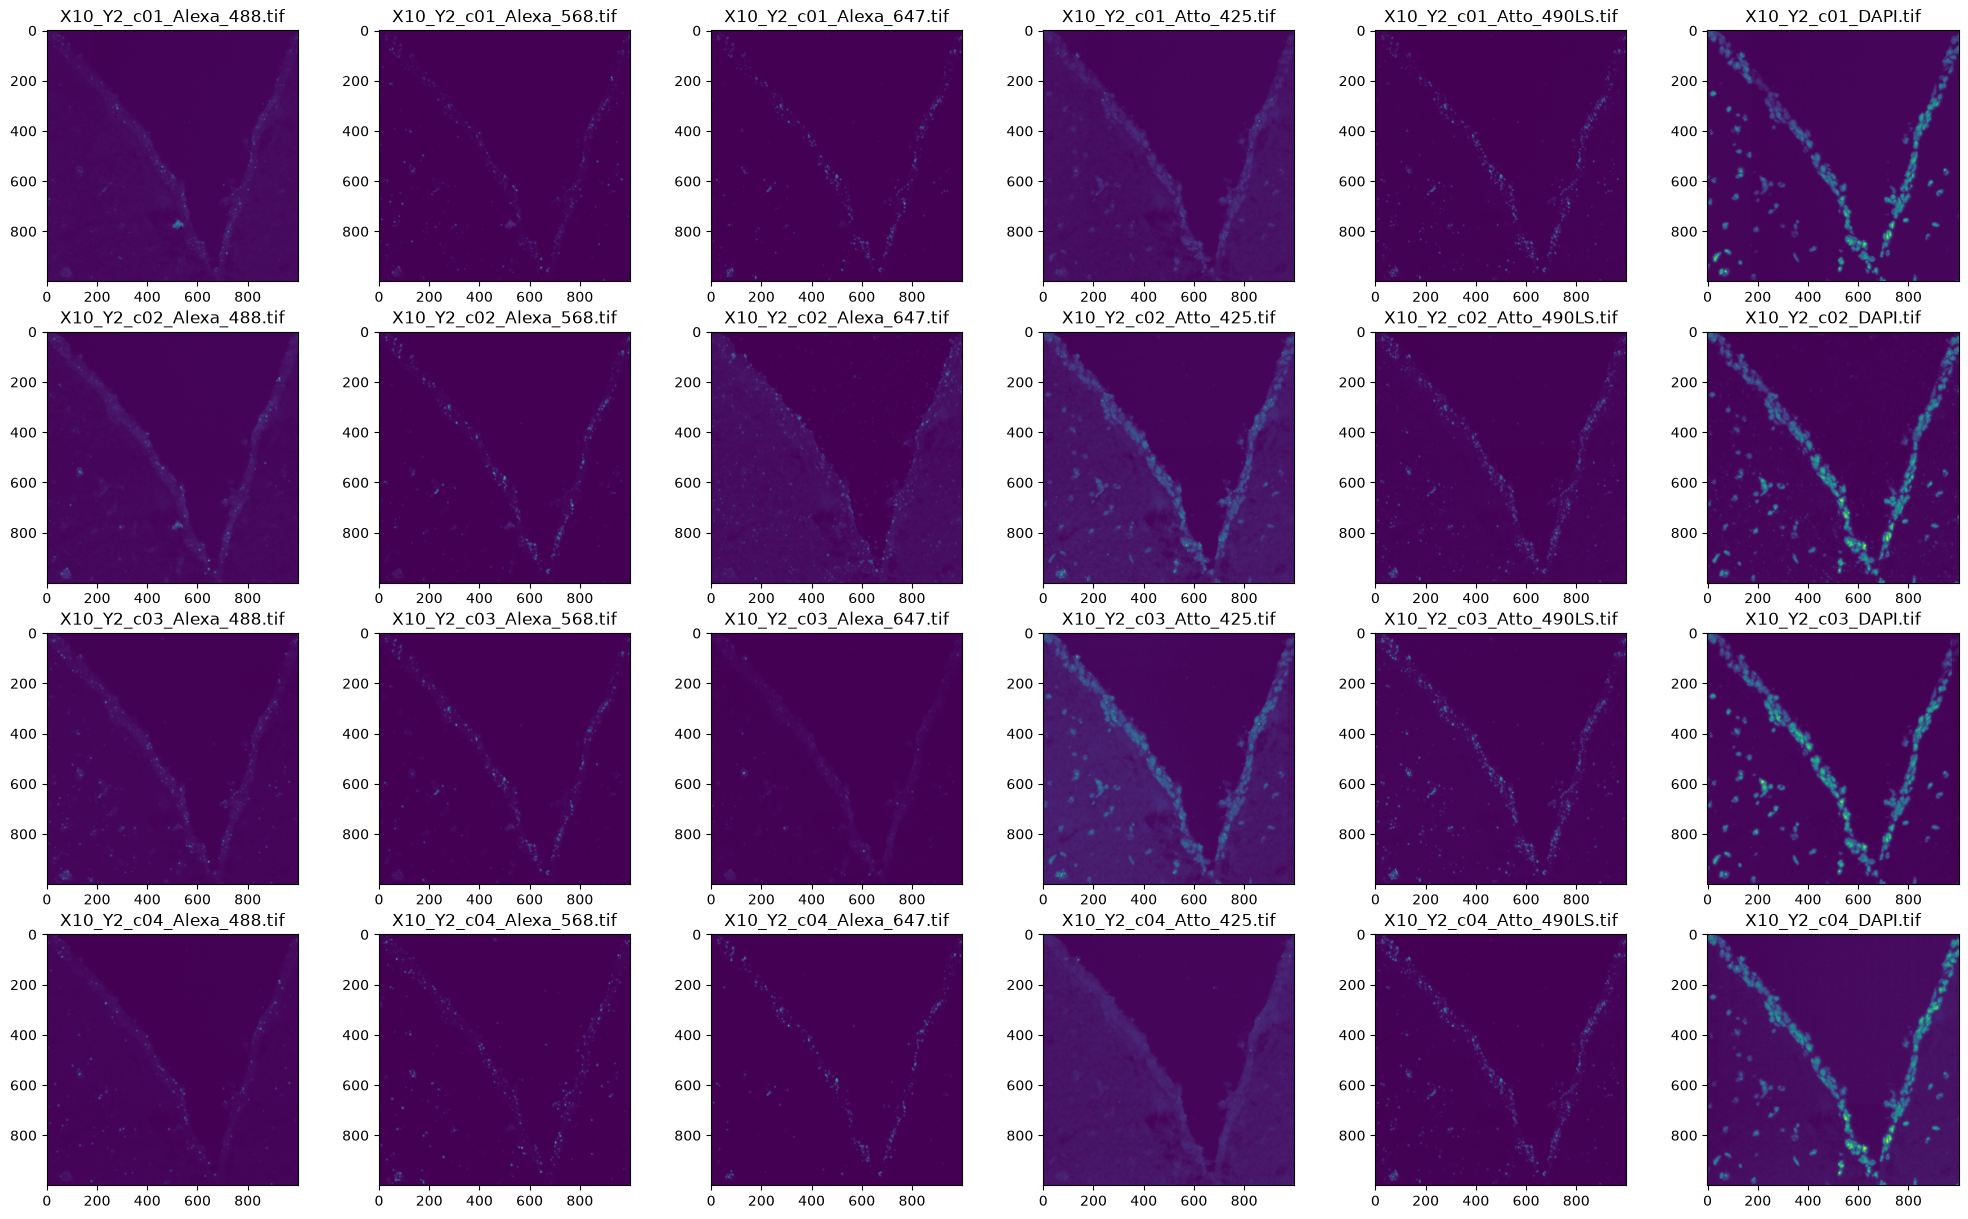

In [20]:
#13.2 + 13.3 - plot a grid of images - X10_Y10

file_list = sorted(glob.glob(f'{PATH}/out_opt_flow_registered_X10_Y2_*.tif'))

## Read images
list_image = [ski.io.imread(file) for file in file_list] #List comprehension

## Plotting
fig, axs = plt.subplots(4, 6, figsize=(25, 15))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(list_image[i])
    ax.set_title(f'{file_list[i].split("registered_",1)[1]}')
plt.show()

1. Use sorted + glob => list of satisfied directories (sorted) <br>
2. Output of glob is the list of directories => need to read image via ski.io.imread to plot

Image processing workflow<br>
1. read image
2. filters - clean background
3. (histogram - threshold - binary image)/ automated histogram
4. watershed - refinement
5. ID - count - number

14. Nuclei counting <br>
a. Which channel(s) is/are most promising for nucleus segmentation? <br>
b. Which methods can you use, to distinguish between nucleus and the rest? <br>
c. How can you devide the nuclei into separate instances? <br>
d. Which problems occur, how can they be addressed?

14.1. Develop method on a fov <br>

a. Which channel iss the most promising for nucleus segmentation? <br>
=> DAPI image. Classic fluorescent probe for staining cell nuclei. it shows cell nuclei as bright blue spots against a dark background.

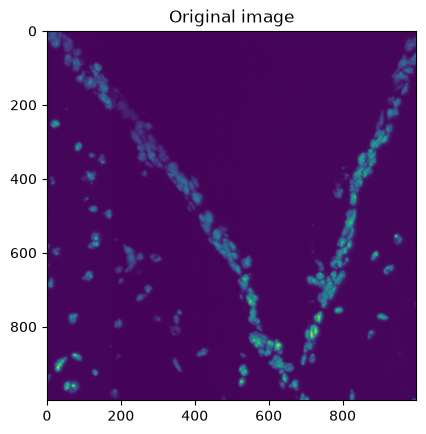

In [21]:
#IMAGE PREPROCESSING

## Read image
path = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y2_c01_DAPI.tif'
im = io.imread(path).astype(np.float32) #
plt.imshow(im)
plt.title('Original image')#draw
plt.show()

Fluorescent images usually have noise => use gaussian filter

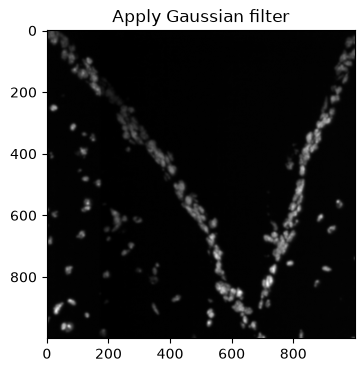

In [22]:
## Apply Gaussian filter
fig = plt.figure(figsize = (8,4)) #create figure

im_gauss = filters.gaussian(im, sigma = 2)
plt.imshow(im_gauss, cmap = 'gray')
plt.title('Apply Gaussian filter')
plt.show()

still have noise -> DOG filter

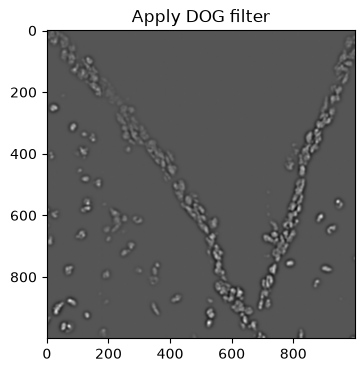

In [23]:
## Apply background substraction

fig3 = plt.figure(figsize = (8,4))
im_dog_1 = difference_of_gaussians(im,low_sigma = 3, high_sigma = 3*1.6)
plt.title('Apply DOG filter')
plt.imshow(im_dog_1, cmap = 'gray')
plt.show()

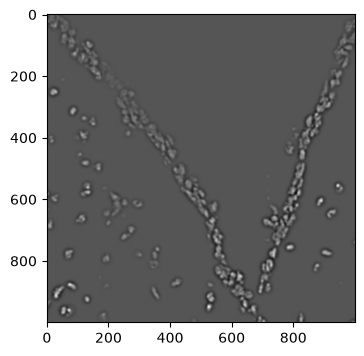

In [24]:
## Apply background substraction - Try to write function
fig4 = plt.figure(figsize = (8,4))

def result_difference_of_gaussians(im, sigma_lower, sigma_higher, clip_negative = True):
    im_dog_2 = difference_of_gaussians(im, low_sigma = sigma_lower, high_sigma = sigma_higher)
    return im_dog_2

im_dog_result = result_difference_of_gaussians(im, 3, 3*1.6)
plt.imshow(im_dog_result, cmap = 'gray') #pass image_show as argument to imshow
plt.show()

Image still has tiny noise => apply morphological opening after having binary image

-103.89664 205.59131 float32


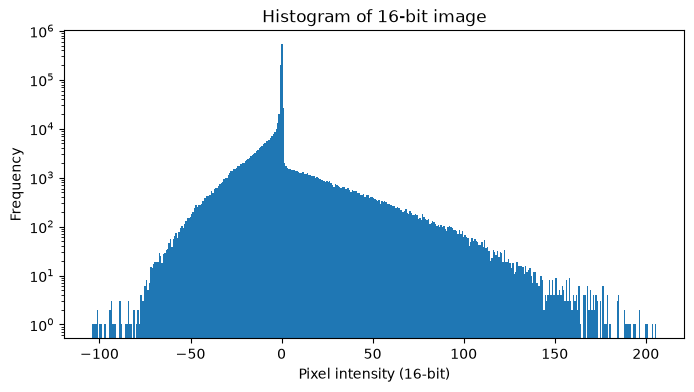

In [25]:
## Create binary image based on thresholding
## Show histogram
print(im_dog_result.min(), im_dog_result.max(), im_dog_result.dtype) #check min and max => check range of image

fig5 = plt.figure(figsize = (8,4))

plt.hist(im_dog_result.flatten(), bins= 400, range=(im_dog_result.min(), im_dog_result.max()), log = True)
plt.xlabel('Pixel intensity (16-bit)')
plt.ylabel('Frequency')
plt.title('Histogram of 16-bit image')
plt.show()

Misunderstanding: use original image to plot histogram and decide type of thresholding => should use gauss_image to plot histogram

right - skewed, unimodal histogram => Triangle threshold or self - choosing threshold<br>
Sharp spike at 0: most pixels are flat background, so the DoG (difference of two blurred images) is near 0. <br>
Gradual left slope: negative pixels, mostly the dark halo around bright objects. <br>
Sharp drop-> long right tail: the positive part, the cores of the bright objects ??!!!



<Figure size 800x400 with 0 Axes>

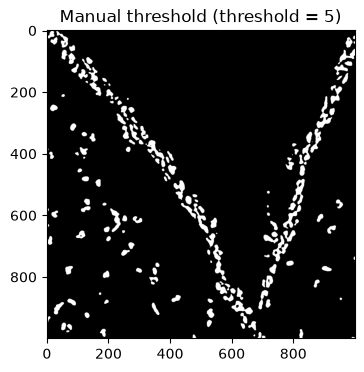

In [26]:
## Apply self- choosing threshold
#set threshold
thresh = 5

#show result
fig6 = plt.figure(figsize = (8,4))
binary_image_manual = im_dog_result > thresh

plt.figure(figsize=(8, 4))
plt.imshow(binary_image_manual, cmap='gray')
plt.title(f'Manual threshold (threshold = {thresh})')
plt.show()

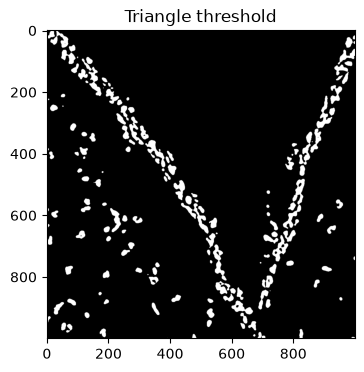

In [27]:
## Apply triangle threshold
binary_image_triangle = im_dog_result > threshold_triangle(im_dog_result)
plt.figure(figsize=(8, 4))
plt.title(f'Triangle threshold')
plt.imshow(binary_image_triangle, cmap='gray')

The result from automatic threshold and manula threshold are quite same. Still have tiny noise => need morphological opening<br>
The manual threshold setting applies only to the specific FOV you are viewing; if we switch to a different FOV with different brightness or gain settings, we must reconfigure each one individually. <br>
=> Automatic settings, however, apply the same rule to every image, ensuring reproducible results.

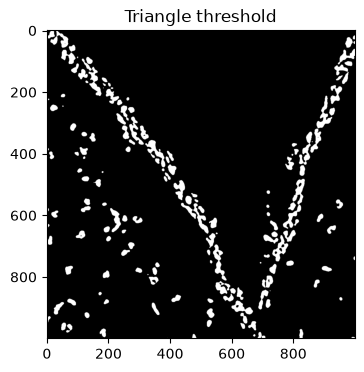

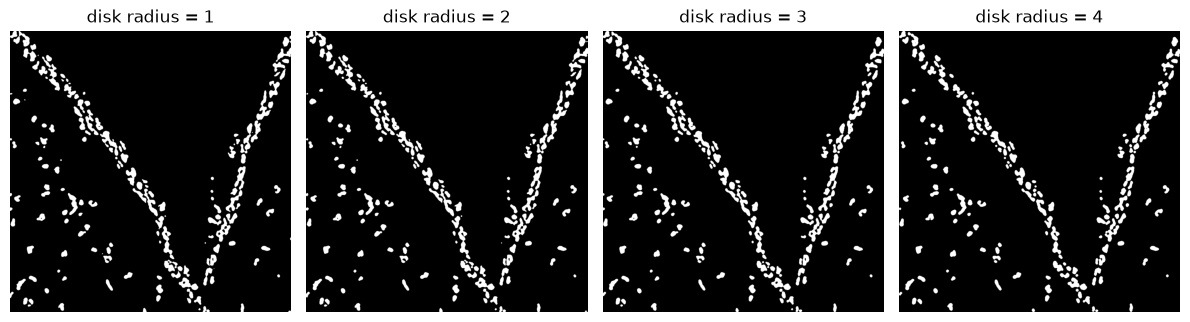

In [58]:
## Apply morphological opening - try with several disk values

radius_value = [1,2,3,4]
list_image_opened = []
def morphological_opening(binary_image, radius):
    image_opened = ndimage.binary_opening(binary_image, structure = ski.morphology.disk(radius))
    return image_opened

for r in radius_value:
    image_opened_list = morphological_opening(binary_image_triangle, r)
    list_image_opened.append(image_opened_list)

## Plotting
plt.figure(figsize=(8, 4))
plt.title(f'Triangle threshold')
plt.imshow(binary_image_triangle, cmap='gray')

fig, axes = plt.subplots(1,4, figsize = (12,8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(list_image_opened[i], cmap='gray')
    ax.set_title(f'disk radius = {radius_value[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Choose radius  = 4 for next step
image_opened = list_image_opened[3]


1. disk = [1,2] - too small to delete noise <br>
2. disk = 3 => much better but still contains noise on the left side => choose 4 <br>
3. problem: connected nuclei -> separate by watershed

Number of markers: 295
Number of object after watershed: 328


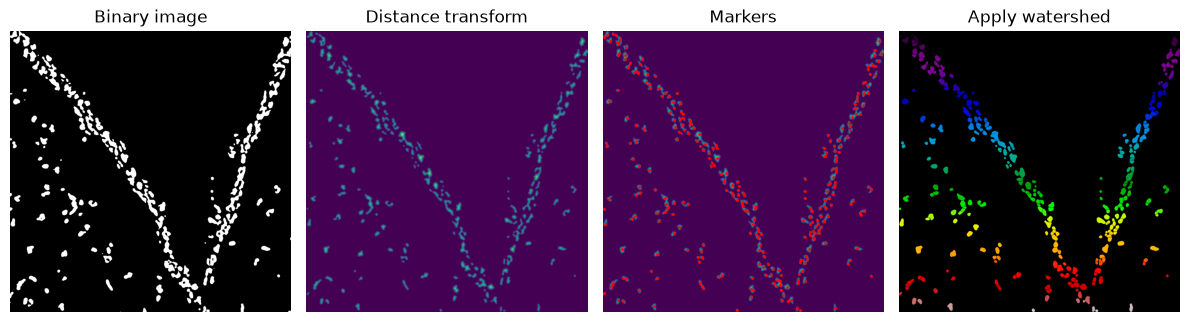

In [59]:
# Manual watershed

## Distance transform
distance = ndimage.distance_transform_edt(image_opened) #syntax

## Find local maxima
coords = peak_local_max(distance, min_distance= 5, labels=image_opened)
mask = np.zeros(distance.shape, dtype=bool) #Ask claude
mask[tuple(coords.T)] = True #Ask claude
markers, num_markers = ndimage.label(mask)
print(f"Number of markers: {num_markers}")

## Watershed
image_watershed = watershed(-distance, markers=markers, mask=image_opened, watershed_line=True)
print(f"Number of object after watershed: {labels.max()}")

## Plotting
images = [binary_image_triangle, distance, distance, image_watershed]
cmaps = ['gray','viridis', 'viridis', 'nipy_spectral']
titles = ['Binary image', 'Distance transform', 'Markers', 'Apply watershed']

fig,axes = plt.subplots(1,4, figsize = (12,8))
for i, ax in enumerate(axes):
    ax.imshow(images[i], cmap = cmaps[i])
    ax.set_title(titles[i])
    ax.axis("off")

axes[2].plot(coords[:,1], coords[:,0],'r.', markersize =2)
plt.tight_layout()
plt.show()

1. Main target of doing manual watershed is to understand how progress works step by step. <br>
2. How to choose min_distance => calculate median size of spot -> min_distance must smaller than that. In this case the median is 6.xx => choose min_distance =4 or 5 <br>
2. syntax "r" in markersize => need to be "r." <br>
3. Remember to use enumerate when plotting(subplot) -> shorter. which case need flatten() or not? -> 1D array => no need flatten.

Number of object after watershed: 895


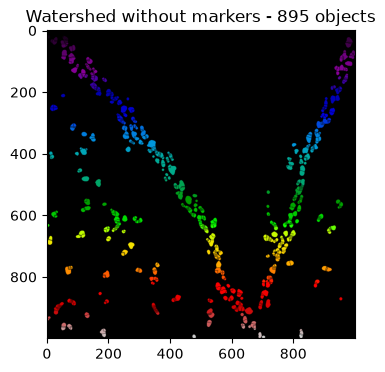

In [60]:
# Manual watershed without markers
labels_automated = watershed(-distance, markers=None, mask=image_opened, watershed_line=True)
print(f"Number of object after watershed: {labels_automated.max()}")
plt.figure(figsize=(8,4))
plt.imshow(labels_automated, cmap='nipy_spectral')
plt.title(f'Watershed without markers - {labels_automated.max()} objects')
plt.show()

Add markers for watershed, because: without markers, the algorithm will automatically locate all local maxima in image (although they are noises) and treat them as real markers -> oversegmentation

In [71]:
## Automated watershed
image_dist = ndimage.distance_transform_edt(image_opened)
image_max = extrema.h_maxima(image_dist, 0.5)
image_max = ndimage.binary_dilation(image_max, structure=np.ones((3, 3)))
image_max = np.bitwise_and(image_opened, image_max)
image_label, n = ndimage.label(image_max)
image_watershed = watershed(-image_dist, markers=image_label, mask=image_opened, watershed_line=True)
image_cleaned = image_watershed > 0
number_nuclei = image_watershed.max()
print(n,number_nuclei)


270 270


Text(0.5, 1.0, 'Distinguish nuclei ')

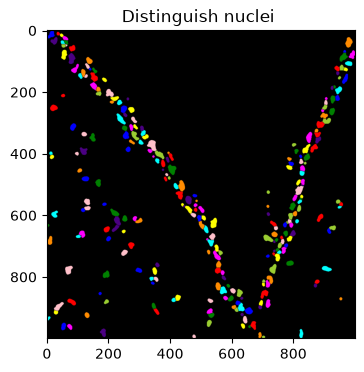

In [72]:
## Distinguish objects

im_distinguish = label2rgb(image_watershed, bg_label = 0, bg_color = 'black')
plt.figure(figsize = (8,4))
plt.imshow(im_distinguish)
plt.title("Distinguish nuclei ")

Prefer to use automated watershed: <br>
- "h" - minimum depth of the neck in the distance map, depends less on the distance between the centers. <br>
- when use  min_distance => need to look at the size of nuclei -> decide -> longer time and bias

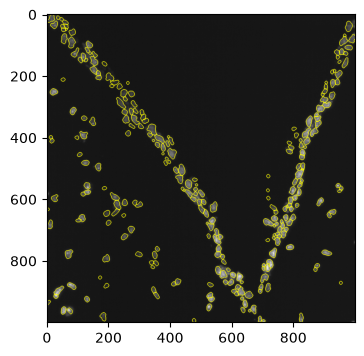

In [75]:
## Draw the boundaries
image_normalize = im / im.max()  # normalize to [0,1]
image_rgb = gray2rgb(image_normalize)
boundary_image = mark_boundaries(image_rgb, image_watershed, mode='thick')
plt.figure(figsize = (8,4))
plt.imshow(boundary_image)
plt.show()

mark boundary funtion: input(float[0,1] => need to normalize the original image beforehand

lab_spots = watershed(-bw_spots_dist, markers = lab_spots, mask =bw_image_cleanup,  watershed_line=True) <br>
mask => water is allowed to expand inside the (bw_image_cleanup) range. - not expanding to background <br>
Misunderstanding: noise in this image is not salt - pepper noise => no need median filter


Most basical step for image preprocessing before counting nuclei is: binary image, watershed. <br>
- The application of filters to clean up image should be considered after each processing step (once binary image has been reviewed, filters can be applied to handle noise/speckle) <br>
- One problem: still have speckle. This is the time to filter nuclei by size.

In [83]:
## Filtering by size

props = regionprops_table(image_watershed, properties=['label', 'centroid', 'area'])
df = pd.DataFrame(props)

df_filtered = df[df['area'] > 50].copy()

print(f"Before filtering: {len(df)} nuclei")
print(f"After filtering (area > 50): {len(df_filtered)} nuclei")
df_filtered.to_csv('/Users/chann/Downloads/F1 Systems bio/Project/code/Results/Intermediates/Nuclei counting/nuclei_coordinates_X10_Y2_c01.csv', index=False)


Before filtering: 270 nuclei
After filtering (area > 50): 260 nuclei


Simplest way to filter noise in image by size: <br>
- view image through Fiji => have first glance of nuclei's size
- Try to see size of noise => filter according to this size

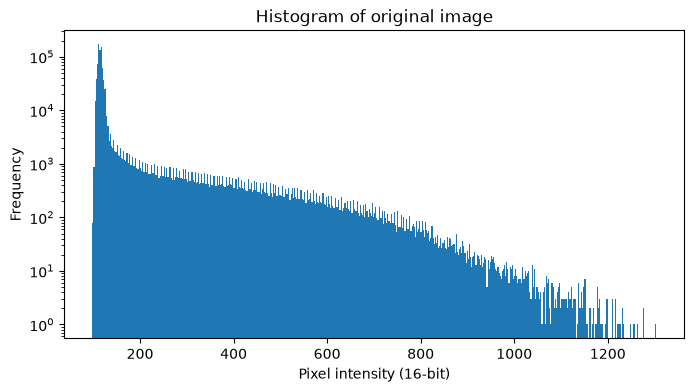

In [125]:
# SUMMERIZE - X10_Y2_c01

# 1. Read original image
path = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y2_c01_DAPI.tif'
im = io.imread(path).astype(np.float32)

#2. Create the histogram => see the overall structure => 1 peaks (unimodal) => triangle thresholding <> two peak => otsu
fig = plt.figure(figsize=(8, 4))
im_hist = plt.hist(im.ravel(), bins=512, range=(im.min(), im.max()),log = True)  #the darkest value and brightest value of pixel
plt.xlabel('Pixel intensity (16-bit)')
plt.ylabel('Frequency')
plt.title('Histogram of original image')
plt.show()

In [126]:
# 3. IMAGE PREPROCESSING

## Apply Gaussian filter
im_gauss = filters.gaussian(im, sigma=1)

## Apply difference of Gaussian filter (1)
im_dog = difference_of_gaussians(im_gauss, low_sigma=3, high_sigma=3 * 1.6)

## Apply thresholding => still have noise and connected nuclei
im_threshold = im_dog > threshold_triangle(im_dog)

## Count the number of nuclei after thresholding: to check number of nuclei before and after morphological opening
labeled_array, num_features = ndimage.label(im_threshold)
print(f"Number of nuclei after thresholding: {num_features}")

## Apply morphological opening:
#still have noise -> use erosion and dilation to solve it. Necessary thing when we'll do watershed. Disk: create the circular structure element <> extrema: min, max
structure_element = disk(3)
im_opened = ndimage.binary_opening(im_threshold, structure=structure_element)
labeled_array, num_features = ndimage.label(im_opened)
print(f'Number of nuclei after morphological opening: {num_features}')

## Apply watershed

## distance transform => calculate the distance from bright spot to the closest black spots.
im_dist = distance_transform_edt(im_opened)
im_dist = np.round(im_dist)

## define the seed (markers): There is a lot of tiny maxima (included noise) -> we use H - maxima to find only the larger maximan => dilate them to resist the too much close distance between seeds.
im_maxima = extrema.h_maxima(im_dist, 0.5)
im_maxima = ndimage.binary_dilation(im_maxima)
im_maxima = im_maxima & im_opened  #set the limitation -> make sure we will not dilate them beyond the boundary of image
lab_seeds, n = ndimage.label(im_maxima)  #count and give them ID => lab_seeds is the result after giving them ID(array) -> n= total number of seeds(integer)
labeled_array, num_features = ndimage.label(im_maxima)
print(f'Number of seeds: {n}')

## apply the watershed
im_water = watershed(-im_dist, markers=lab_seeds, mask=im_opened, watershed_line=True)
print(f'Number of nuclei after watershed:{n}')

## Apply boundaries
im_norm = im / im.max()  # normalize to [0,1]
im_rgb = gray2rgb(im_norm)
im_bound = mark_boundaries(im_rgb, im_water, mode='median')

Number of nuclei after thresholding: 159
Number of nuclei after morphological opening: 161
Number of seeds: 270
Number of nuclei after watershed:270


In [127]:
# 4. Export nuclei coordinates and filtering
props = regionprops_table(im_water, properties=['label', 'centroid', 'area'])
df = pd.DataFrame(props)

## Filtering
df_filtered = df[df['area'] > 50].copy()
print(f"Before filtering: {len(df)} nuclei")
print(f"After filtering (area > 50): {len(df_filtered)} nuclei")

## Save as csv
df_filtered.to_csv('/Users/chann/Downloads/F1 Systems bio/Project/code/Results/Intermediates/Nuclei counting/nuclei_coordinates_X10_Y2_c01_summerize.csv', index=False)

Before filtering: 270 nuclei
After filtering (area > 50): 257 nuclei


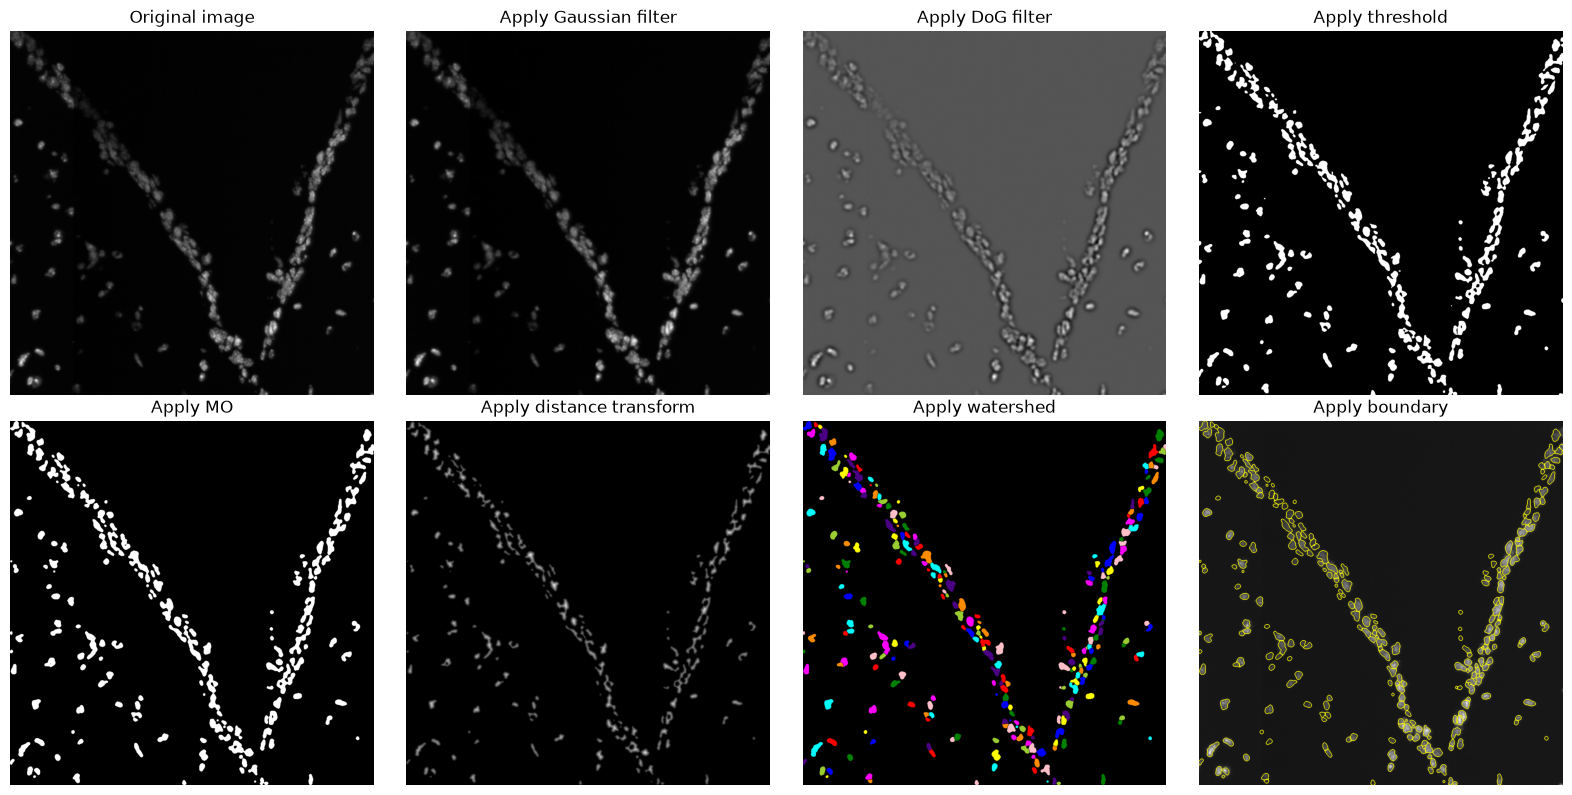

In [128]:
# 5. Plotting

def create_figure(figsize=(8, 4)):
    return plt.figure(figsize=figsize)

def show_image(img, title='', pos=111, cmap='gray'):
    plt.subplot(pos)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')

def glue_fig(name):
    plt.tight_layout()
    plt.savefig(f"{name}.png")
    plt.show()

fig = create_figure(figsize=(16, 8))

show_image(im, title='Original image', pos=241)
show_image(im_gauss, title='Apply Gaussian filter', pos=242, cmap='gray')
show_image(im_dog, title='Apply DoG filter', pos=243, cmap='gray')
show_image(im_threshold, title='Apply threshold', pos=244, cmap='gray')
show_image(im_opened, title='Apply MO', pos=245, cmap='gray')
show_image(im_dist, title='Apply distance transform', pos=246)
show_image(label2rgb(im_water, bg_label=0, bg_color='black'), title='Apply watershed', pos=247)
show_image(im_bound, title='Apply boundary', pos=248, cmap='gray')

glue_fig('fig_overview_workflow')

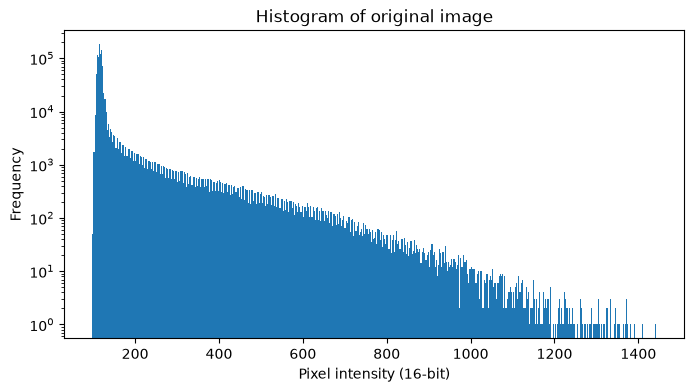

In [119]:
# TRY WITH OTHER FOVS
# X10_Y3_c01

# 1. Read original image
path = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y3_c01_DAPI.tif'
im_X10_Y3 = io.imread(path).astype(np.float32)

#2. Create the histogram
fig = plt.figure(figsize=(8, 4))
im_hist = plt.hist(im_X10_Y3.ravel(), bins=512, range=(im.min(), im.max()),
                   log=True)  #the darkest value and brightest value of pixel
plt.xlabel('Pixel intensity (16-bit)')
plt.ylabel('Frequency')
plt.title('Histogram of original image')
plt.show()


In [120]:
# 3. IMAGE PREPROCESSING

## Apply Gaussian filter
im_gauss_1 = filters.gaussian(im_X10_Y3, sigma=1)

## Apply difference of Gaussian filter (1)
im_dog_1 = difference_of_gaussians(im_gauss_1, low_sigma=3, high_sigma=3 * 1.6)

## Apply thresholding => still have noise and connected nuclei
im_threshold_1 = im_dog_1 > threshold_triangle(im_dog_1)

## Count the number of nuclei after thresholding: to check number of nuclei before and after morphological opening
labeled_array, num_features = ndimage.label(im_threshold_1)
print(f"Number of nuclei after thresholding: {num_features}")

## Apply morphological opening:
#still have noise -> use erosion and dilation to solve it. Necessary thing when we'll do watershed. Disk: create the circular structure element <> extrema: min, max
structure_element = disk(3)
im_opened_1 = ndimage.binary_opening(im_threshold_1, structure=structure_element)
labeled_array_1, num_features_1 = ndimage.label(im_opened_1)
print(f'Number of nuclei after morphological opening: {num_features}')

## Apply watershed

## distance transform => calculate the distance from bright spot to the closest black spots.
im_dist_1 = distance_transform_edt(im_opened_1)
im_dist_1 = np.round(im_dist_1)

## define the seed (markers): There is a lot of tiny maxima (included noise) -> we use H - maxima to find only the larger maximan => dilate them to resist the too much close distance between seeds.
im_maxima_1 = extrema.h_maxima(im_dist_1, 0.5)
im_maxima_1 = ndimage.binary_dilation(im_maxima_1)
im_maxima_1 = im_maxima_1 & im_opened_1  #set the limitation -> make sure we will not dilate them beyond the boundary of image
lab_seeds_1, n1 = ndimage.label(
    im_maxima_1)  #count and give them ID => lab_seeds is the result after giving them ID(array) -> n= total number of seeds(integer)
labeled_array_1, num_features_1 = ndimage.label(im_maxima_1)
print(f'Number of seeds: {n1}')

## apply the watershed
im_water_1 = watershed(-im_dist_1, markers=lab_seeds_1, mask=im_opened_1, watershed_line=True)
print(f'Number of nuclei after watershed:{n1}')

## Apply boundaries
im_norm_1 = im_X10_Y3 / im_X10_Y3.max()  # normalize to [0,1]
im_rgb_1 = gray2rgb(im_norm_1)
im_bound_1 = mark_boundaries(im_rgb_1, im_water_1, mode='median')

Number of nuclei after thresholding: 244
Number of nuclei after morphological opening: 244
Number of seeds: 375
Number of nuclei after watershed:375


In [121]:
# 4. Export nuclei coordinates and filtering
props = regionprops_table(im_water_1, properties=['label', 'centroid', 'area'])
df = pd.DataFrame(props)

## Filtering
df_filtered_1 = df[df['area'] > 50].copy()
print(f"Before filtering: {len(df)} nuclei")
print(f"After filtering (area > 50): {len(df_filtered_1)} nuclei")

## Save as csv
# df_filtered.to_csv(
#     '/Users/chann/Downloads/F1 Systems bio/Project/code/Results/Intermediates/Nuclei counting/nuclei_coordinates_X10_Y3_c01_summerize.csv',
#     index=False)

Before filtering: 375 nuclei
After filtering (area > 50): 363 nuclei


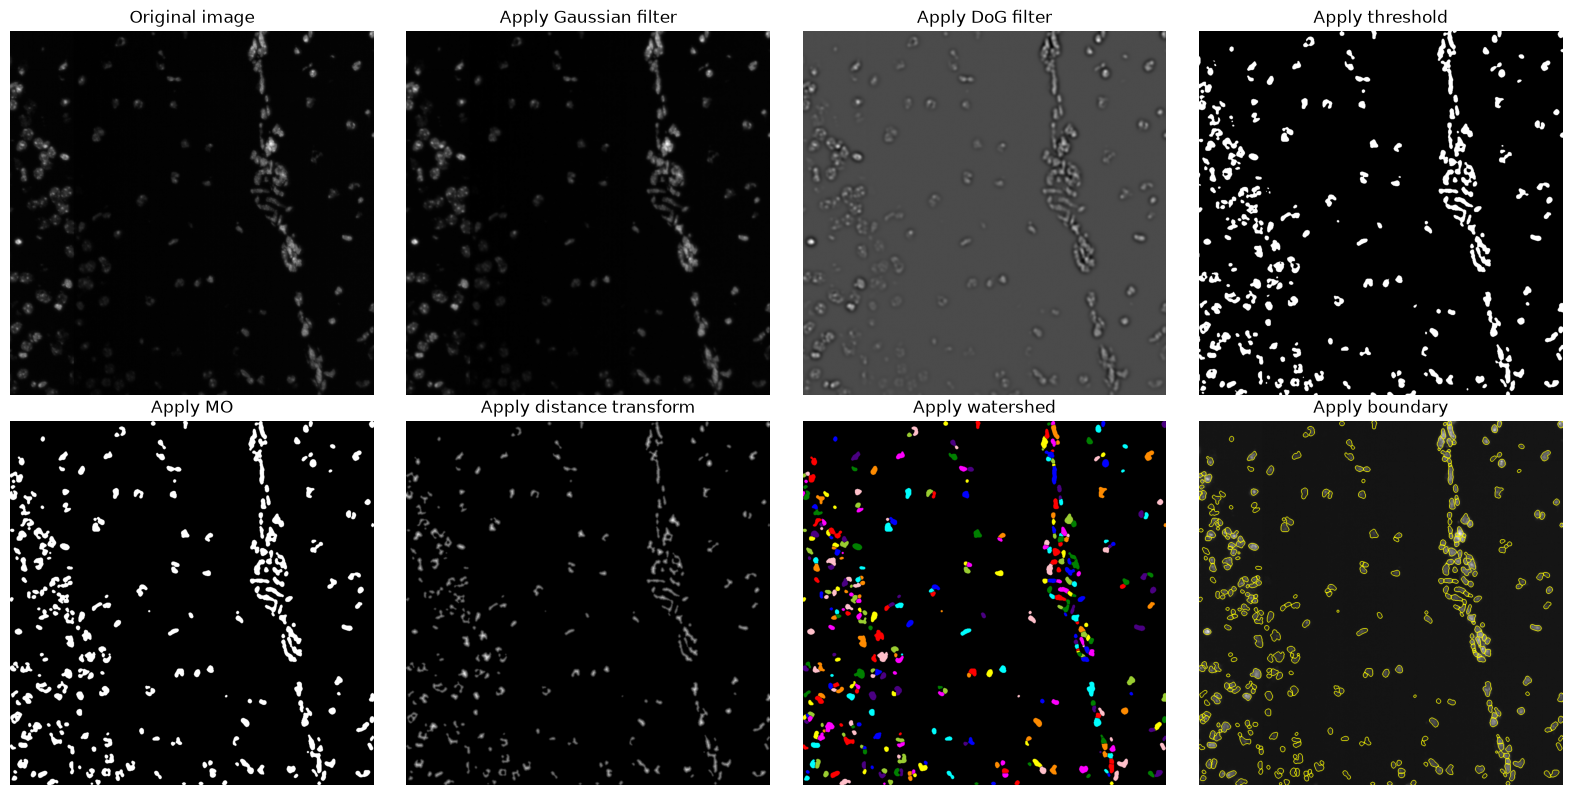

In [124]:
# 5. Plotting

def create_figure(figsize=(8, 4)):
    return plt.figure(figsize=figsize)


def show_image(img, title='', pos=111, cmap='gray'):
    plt.subplot(pos)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')


def glue_fig(name):
    plt.tight_layout()
    plt.savefig(f"{name}.png")
    plt.show()


fig = create_figure(figsize=(16, 8))

show_image(im_X10_Y3, title='Original image', pos=241)
show_image(im_gauss_1, title='Apply Gaussian filter', pos=242, cmap='gray')
show_image(im_dog_1, title='Apply DoG filter', pos=243, cmap='gray')
show_image(im_threshold_1, title='Apply threshold', pos=244, cmap='gray')
show_image(im_opened_1, title='Apply MO', pos=245, cmap='gray')
show_image(im_dist_1, title='Apply distance transform', pos=246)
show_image(label2rgb(im_water_1, bg_label=0, bg_color='black'), title='Apply watershed', pos=247)
show_image(im_bound_1, title='Apply boundary', pos=248, cmap='gray')

glue_fig('fig_overview_workflow')

14.1. Develop method on a fov <br>

a. Which channel iss the most promising for nucleus segmentation? <br>
=> DAPI image. Classic fluorescent probe for staining cell nuclei. it shows cell nuclei as bright blue spots against a dark background.

b. Which methods can you use to distinguish between nucleus and the rest? <br>
- Basically: nucleus: foreground <> the rest: background. We use thresholding method to separate them. After applying threshold: nuclei become white spot and the background is black. <br>
- However, because of the noise, we need to apply some filters with suitable index. This is the step we have try many time and give the most suitable one. <br>
- Applied filters: Gaussian(sigma = 1), difference of gaussian filter(sigma1 = 3, sigma2 = sigma1*1.6), morphological opening(radius of disk = 3) (reference: based on Robert Hasse) <br>

c. How can you divide the nuclei into separate instances? <br>
- I used watershed (module: skimage.segmentation - package: skimage) (tried 2 ways to find markers). Finally, I choose h - maxima to do this. <br>
- Breaking algorithm down into steps helps me better visualize the progress.

d. Which problems occur, how can they be addressed? <br>
- Understand how the filters work and choose them reasonably + choose suitable index for them => read documentation + study Robert Hasse study course on Youtube <br>
- Get used to with pandas, dataframe => practice <br>
- Misunderstanding the type of noise (salt - pepper noise and shot noise/read noise) => watch video to identify <br>
- Forgot syntax !!! => Practice, Practice, Practice.

In [ ]:
# Nuclei counting (all C01 DAPI images)
## take the path of folder
folder = "/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/"

GAUSSIAN_SIGMA = 1
DOG_LOW_SIGMA = 3
DOG_HIGH_SIGMA = DOG_LOW_SIGMA * 1.6
DISK_RADIUS = 3
H_MAXIMA_THRESHOLD = 0.5
AREA_MIN = 50


In [144]:
## 1 DAPI image
def count_c01_nuclei(image_path):
    im = io.imread(image_path).astype(np.float32)
    im_gauss = filters.gaussian(im, sigma=GAUSSIAN_SIGMA)
    im_dog = difference_of_gaussians(im_gauss, low_sigma=DOG_LOW_SIGMA, high_sigma=DOG_HIGH_SIGMA)
    im_threshold = im_dog > threshold_triangle(im_dog)
    im_opened = ndimage.binary_opening(im_threshold, structure=disk(DISK_RADIUS))
    im_dist = np.round(distance_transform_edt(im_opened))
    im_maxima = extrema.h_maxima(im_dist, H_MAXIMA_THRESHOLD)
    im_maxima = ndimage.binary_dilation(im_maxima) & im_opened
    lab_seeds, _ = ndimage.label(im_maxima)
    im_water = watershed(-im_dist, markers=lab_seeds, mask=im_opened, watershed_line=True)

    # Filtering (area > 50)
    props = regionprops_table(im_water, properties=["label", "centroid", "area"])
    df = pd.DataFrame(props)
    df_filtered = df[df["area"] > AREA_MIN]

    return len(df_filtered)

In [145]:
## Get all c01 DAPI images (190 images)
c01_paths = sorted(glob.glob(PATH + "*_c01_DAPI.tif"))
results = []

for path in c01_paths:
    filename = os.path.basename(path)
    fov_name = filename.split("registered_")[-1].split("_c")[0]
    nuclei_count = count_c01_nuclei(path)
    results.append({"FOV": fov_name, "Round1_Count": nuclei_count})

# Create data frame => save as csv
df_results = pd.DataFrame(results)
output_path = "/Users/chann/Downloads/F1 Systems bio/Project/code/Results/Intermediates/Nuclei counting/nuclei_counting_all_fov_c01_only.csv"
df_results.to_csv(output_path, index=False)

print(df_results)

         FOV  Round1_Count
0    X10_Y10           322
1    X10_Y11           388
2    X10_Y12           508
3    X10_Y13           470
4    X10_Y14           376
..       ...           ...
185   X23_Y4             1
186   X23_Y5            51
187   X23_Y6            77
188   X23_Y7            75
189   X23_Y8            54

[190 rows x 2 columns]


The above part is for image processing and nuclei counting for one DAPI image per fov. However, it is better to count the number of nuclei in all 4 DAPI images/ fov and get their mean. <br>
This progress is divided into 3 main parts: nuclei conting for 1 DAPI image => 4 DAPI images/fov => mean <br>
Try with 1 fov first => all of fovs after

In [34]:
# List of all DAPI image per 1 fov

paths = sorted(glob.glob(f'{PATH}/out_opt_flow_registered_X10_Y10_*DAPI.tif'))
print(paths) # have not sorted -> need to sort

['/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y10_c01_DAPI.tif', '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y10_c02_DAPI.tif', '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y10_c03_DAPI.tif', '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y10_c04_DAPI.tif']


In [150]:

# 1 DAPI image
def count_nuclei_one_round(image_path): #only use in function
    im = io.imread(image_path).astype(np.float32)
    im_gauss = filters.gaussian(im, sigma=GAUSSIAN_SIGMA)
    im_dog = difference_of_gaussians(im_gauss, low_sigma=DOG_LOW_SIGMA, high_sigma=DOG_HIGH_SIGMA)
    im_threshold = im_dog > threshold_triangle(im_dog)
    im_opened = ndimage.binary_opening(im_threshold, structure=disk(DISK_RADIUS))

    im_dist = np.round(distance_transform_edt(im_opened))
    im_maxima = extrema.h_maxima(im_dist, H_MAXIMA_THRESHOLD)
    im_maxima = ndimage.binary_dilation(im_maxima) & im_opened
    lab_seeds, n = ndimage.label(im_maxima)

    im_water = watershed(-im_dist, markers=lab_seeds, mask=im_opened, watershed_line=True)
    im_norm = im / im.max()  # normalize to [0,1]
    im_rgb = gray2rgb(im_norm)
    im_bound = mark_boundaries(im_rgb, im_water, mode='median')
    im_name = image_path.split("registered_")[-1]

    df = pd.DataFrame(regionprops_table(im_water, properties=['label', 'centroid', 'area']))
    return len(df), im, im_gauss, im_dog, im_threshold, im_opened, im_dist, im_water, im_bound, im_name

## Plotting
def show_image(img, title='', pos=111, cmap='gray'):
    plt.subplot(pos)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')

def glue_fig(name):
    plt.tight_layout()
    plt.savefig(f"/Users/chann/Downloads/F1 Systems bio/Project/code/Results/Figures/{name}.png", bbox_inches="tight")
    plt.show()

def im_plot(im, im_gauss, im_dog, im_threshold, im_opened, im_dist, im_water, im_bound, im_name):
    fig = plt.figure(figsize=(16, 8))
    fig.suptitle(im_name) # supertitle for big fig

    show_image(im, title='Original image', pos=241)
    show_image(im_gauss, title='Apply Gaussian filter', pos=242, cmap='gray')
    show_image(im_dog, title='Apply DoG filter', pos=243, cmap='gray')
    show_image(im_threshold, title='Apply threshold', pos=244, cmap='gray')
    show_image(im_opened, title='Apply MO', pos=245, cmap='gray')
    show_image(im_dist, title='Apply distance transform', pos=246)
    show_image(label2rgb(im_water, bg_label=0, bg_color='black'), title='Apply watershed', pos=247)
    show_image(im_bound, title='Apply boundary', pos=248, cmap='gray')

    glue_fig(f'fig_overview_workflow{im_name}')

In [151]:
# 4 DAPI images
def count_nuclei(folder_path):
    nuclei_counts_dict = {}
    paths = sorted(glob.glob(folder_path + 'out_opt_flow_registered_X10_Y3_c*_DAPI.tif'))#list of paths satisfied above condition
    counts = [] # list of number of nuclei per DAPI image
    ims = [] # list of  big images - contain 4 images
    for path in paths: #
        plot_result = [] #contain 8 images in current round
        len_df, im, im_gauss, im_dog, im_threshold, im_opened, im_dist, im_water, im_bound, im_name = count_nuclei_one_round(path)
        plot_result.append(im)
        plot_result.append(im_gauss)
        plot_result.append(im_dog)
        plot_result.append(im_threshold)
        plot_result.append(im_opened)
        plot_result.append(im_dist)
        plot_result.append(im_water)
        plot_result.append(im_bound)
        plot_result.append(im_name) #im_name
        ims.append(plot_result)
        counts.append(len_df)
        nuclei_counts_dict[path.split("registered_")[-1]] = len_df
    nuclei_counts_dict['mean'] = np.mean(counts)

    #Plot image
    for (im, im_gauss, im_dog, im_threshold, im_opened, im_dist, im_water, im_bound, im_name) in ims: #visualization
        im_plot(im, im_gauss, im_dog, im_threshold, im_opened, im_dist, im_water, im_bound, im_name)
    return nuclei_counts_dict,counts

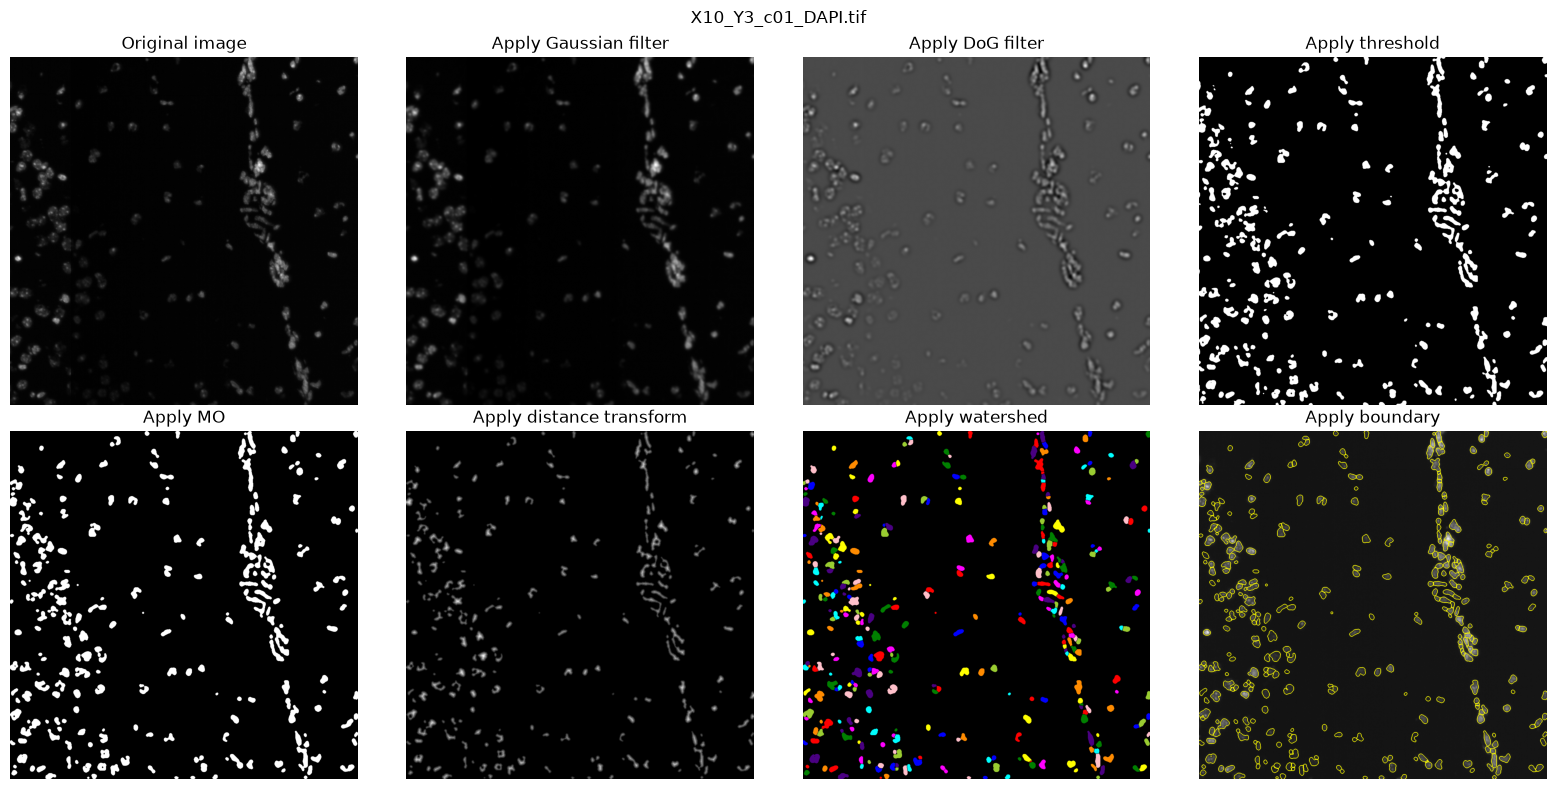

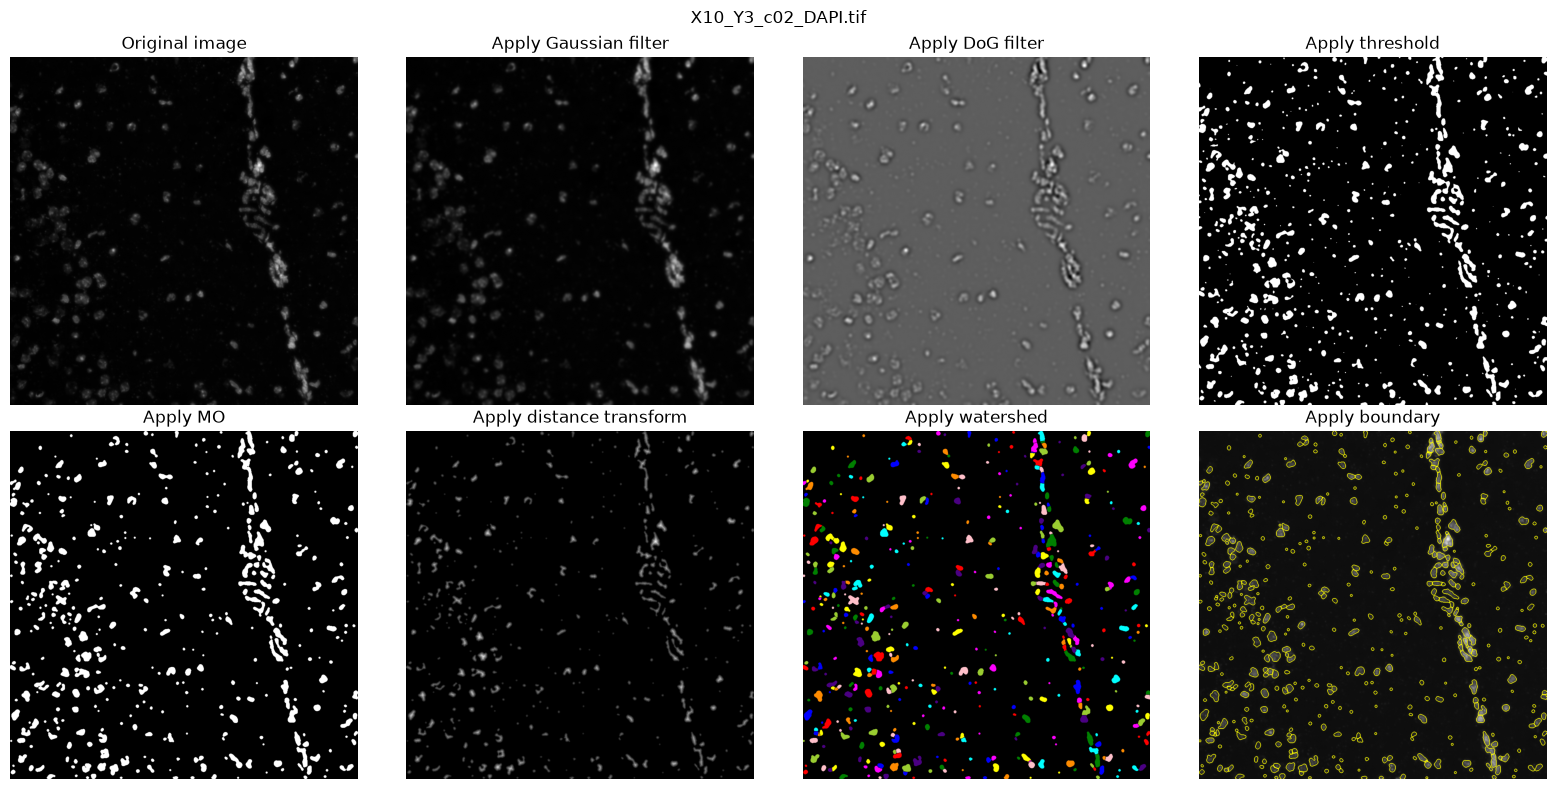

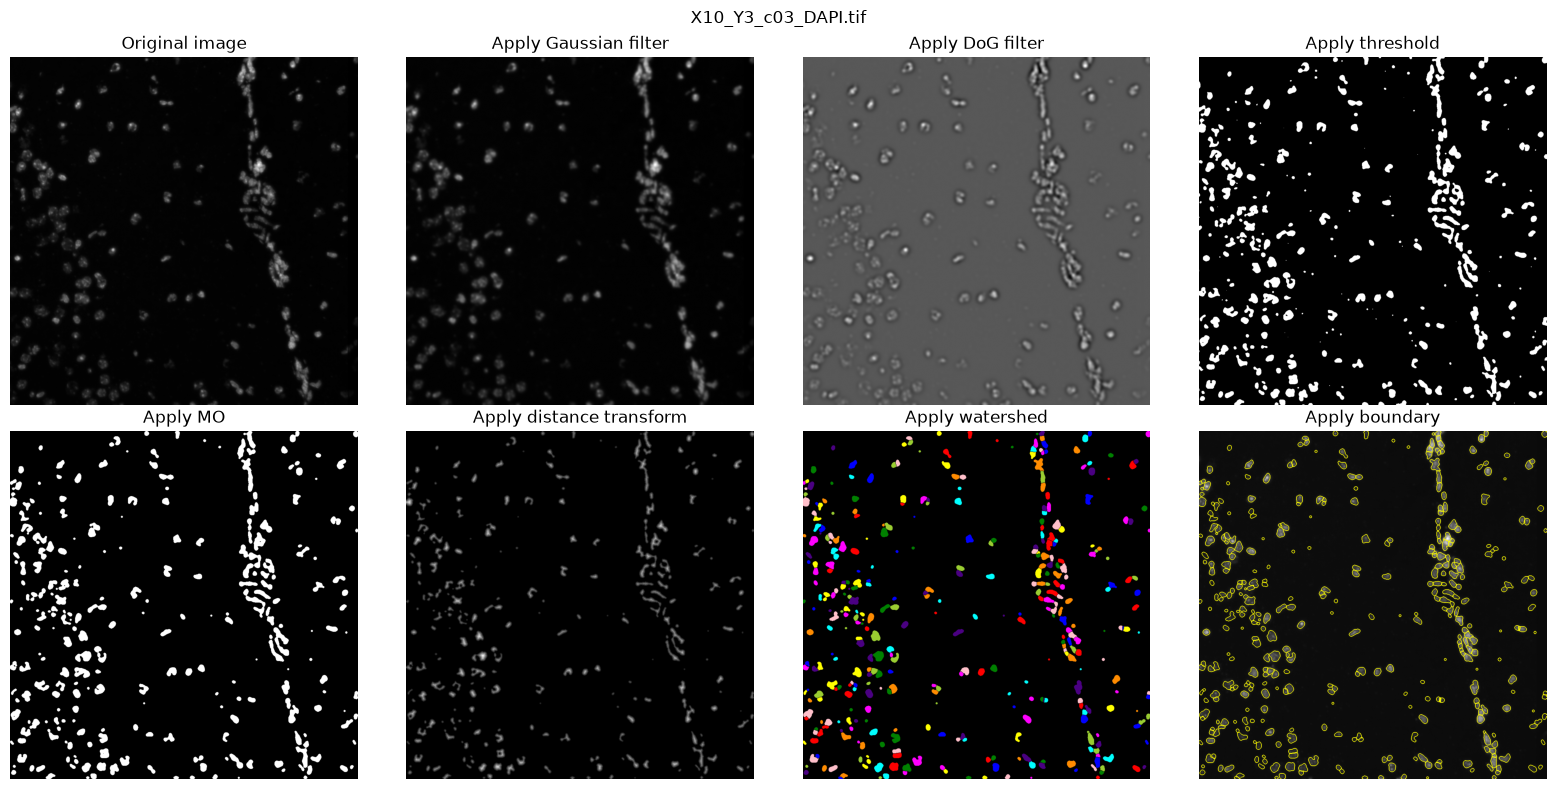

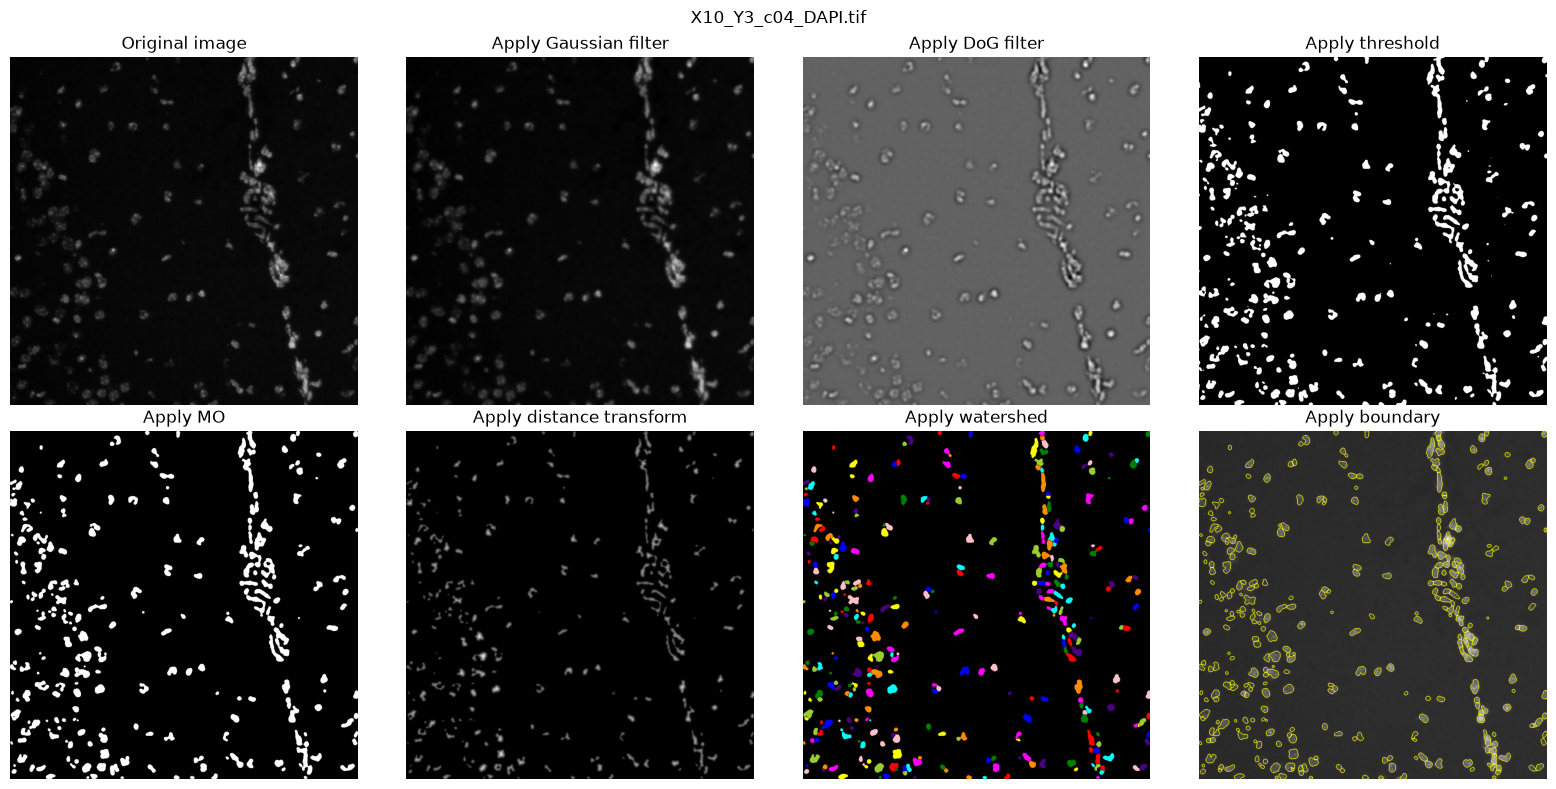

     Name  Round1  Round2  Round3  Round4    Mean
0  X10_Y3     342     484     385     338  387.25


In [152]:
#Number of nuclei
result_nuclei, counts = count_nuclei(PATH)

# Take name of fov from dictionary
image_keys = list(result_nuclei.keys())
image_keys.remove("mean")
fov_name = image_keys[0].split("_c")[0] # from"X10_Y3_c04_DAPI.tif => separate 2 part at 'c' position => take only X10_Y3

row_data = {
    "Name": fov_name,
    "Round1": result_nuclei[image_keys[0]],
    "Round2": result_nuclei[image_keys[1]],
    "Round3": result_nuclei[image_keys[2]],
    "Round4": result_nuclei[image_keys[3]],
    "Mean": result_nuclei["mean"],} #collect the data => put into dictionary -before putting in csv file => purpuse: key => heading, value -> row1

df_result = pd.DataFrame([row_data])
df_result.to_csv("/Users/chann/Downloads/F1 Systems bio/Project/code/Results/nuclei_counts_full.csv",index=False,)

print(df_result)



for path in paths: for each image in list paths => image processing => saved the result (each image) in plot_result => add plot_result into big list ims <br>
for i in ims:visualization: iterate each set of image (saved in ims) => call im_plot -> render the image to screen


Look at the number of nuclei per round, we can see the massive difference between Round 1,3,4 and round 2. To see more => try with other fov

In [168]:

folder = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/'


# 1 DAPI image
def count_nuclei_one_round(image_path):  #only use in function
    im = io.imread(image_path).astype(np.float32)
    im_gauss = filters.gaussian(im, sigma=GAUSSIAN_SIGMA)
    im_dog = difference_of_gaussians(im_gauss, low_sigma=DOG_LOW_SIGMA, high_sigma=DOG_HIGH_SIGMA)
    im_threshold = im_dog > threshold_triangle(im_dog)
    im_opened = ndimage.binary_opening(im_threshold, structure=disk(DISK_RADIUS))

    im_dist = np.round(distance_transform_edt(im_opened))
    im_maxima = extrema.h_maxima(im_dist, H_MAXIMA_THRESHOLD)
    im_maxima = ndimage.binary_dilation(im_maxima) & im_opened
    lab_seeds, n = ndimage.label(im_maxima)

    im_water = watershed(-im_dist, markers=lab_seeds, mask=im_opened, watershed_line=True)
    im_norm = im / im.max()  # normalize to [0,1]
    im_rgb = gray2rgb(im_norm)
    im_bound = mark_boundaries(im_rgb, im_water, mode='median')
    im_name = image_path.split("registered_")[-1]

    df = pd.DataFrame(regionprops_table(im_water, properties=['label', 'centroid', 'area']))
    return len(df), im, im_median, im_gauss, im_dog, im_threshold, im_opened, im_dist, im_water, im_bound, im_name


# 4 DAPI images
def count_nuclei(folder_path, fov):
    nuclei_counts_dict = {}
    paths = sorted(glob.glob(folder_path + f'out_opt_flow_registered_{fov}_c*_DAPI.tif'))  #list of paths satisfied above condition
    counts = []
    for path in paths:
        len_df, im, im_median, im_gauss, im_dog, im_threshold, im_opened, im_dist, im_water, im_bound, im_name = count_nuclei_one_round(
            path)

        counts.append(len_df)
        nuclei_counts_dict[path.split("registered_")[-1].split('_')[2]] = len_df
    nuclei_counts_dict['mean'] = round(np.mean(counts))
    nuclei_counts_dict['name'] = fov

    return nuclei_counts_dict

In [170]:

#Number of nuclei
result_nuclei = [
    count_nuclei(folder,'X11_Y3'),
    count_nuclei( folder, 'X20_Y3'),
    count_nuclei(folder,'X10_Y3'),
    count_nuclei( folder, 'X10_Y12'),
    count_nuclei(folder,'X10_Y8'),
]


In [171]:
pd.DataFrame(result_nuclei)


,c01,c02,c03,c04,mean,name
0,462,592,438,426,480,X11_Y3
1,448,496,482,451,469,X20_Y3
2,342,484,385,338,387,X10_Y3
3,532,601,569,539,560,X10_Y12
4,457,626,500,455,510,X10_Y8


Results from 5 fov turned out: number of nuclei in round 2 >>> other rounds. => calculate all 4 DAPI images make sense.

In [41]:
# 14.2 NUCLEI COUNTING - ALL FOVS

#Apply global variable
DISK = 3
SIGMA = 2
LOW_SIGMA = 3
HIGH_SIGMA = LOW_SIGMA * 1.6
H_MAXIMA_THRESHOLD = 0.5
MIN_AREA = 50


In [161]:
# Count number of nuclei in 1 DAPI image

def one_image(im_path):
    #im_name = im_path.split("registered_")[-1]
    im = io.imread(im_path).astype(np.float32)
    im_gauss = filters.gaussian(im, sigma=SIGMA)
    im_dog = difference_of_gaussians(im_gauss, low_sigma=LOW_SIGMA, high_sigma=HIGH_SIGMA)
    im_threshold = im_dog > threshold_triangle(im_dog)
    im_open = ndimage.binary_opening(im_threshold, disk(DISK))

    im_dist = np.round(distance_transform_edt(im_open))
    im_maxima = extrema.h_maxima(im_dist, H_MAXIMA_THRESHOLD)
    im_maxima = ndimage.binary_dilation(im_maxima) & im_open
    seeds, n = ndimage.label(im_maxima)
    im_water = watershed(im_maxima, markers=seeds, mask=im_open, watershed_line=True)
    #label_image, number_features = ndimage.label(im_water)
    #im_bound = mark_boundaries(im, label_image)

    ## counting and filtering
    df = pd.DataFrame(regionprops_table(im_water, properties=['label', 'area']))
    df_filter = df[df['area'] > MIN_AREA]
    #df.to_csv('result.csv', index = False)

    return len(df_filter)


In [172]:
path_folder = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/'
def cycle_from_path (path):
    return path.split("registered_")[1].split("_")[2]
def four_images(folder, fov_name):
    path_images = sorted(glob.glob(folder + f'out_opt_flow_registered_{fov_name}_c*_DAPI.tif'))
    count_images = []
    count_images_dict = {}
    for path in path_images:
        len_df = one_image(path)
        count_images.append(len_df)
        count_images_dict[cycle_from_path(path)] = len_df  #X10_Y10_c01_DAPI.tif => c01
    count_images_dict['mean'] = round(np.mean(count_images))
    count_images_dict['name'] = fov_name
    return count_images_dict

In [173]:
# All of fov

#Take the list of all fov name
path_folder = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/'
path_fov = glob.glob(path_folder + f'out_opt_flow_registered_*_c01_DAPI.tif')

name_fov = [path.split("registered_")[1].split("_c01")[0] for path in path_fov]  #List comprehension
print(len(name_fov))

190


In [174]:
# Count all fov
count_all = []  #list of dict
for name in name_fov:
    fov_result = four_images(path_folder, name)
    count_all.append(fov_result)


In [175]:

df_all = pd.DataFrame(count_all)
df_all = df_all[['name', 'c01', 'c02', 'c03', 'c04', 'mean']]
df_all.to_csv('/Users/chann/Downloads/F1 Systems bio/Project/code/Results/Intermediates/Nuclei counting/nuclei_counting_4_DAPI_all_fov.csv', index=False)


1. Flow of code: <br> 1 image -> 4 image in 1 fov  -> all of fov <br>
2. Remember assign correct argument for watershed